In [20]:
from pathlib import Path
from pump_probe_analysis.pps import PPS
import matplotlib.pyplot as plt

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Example usage of PPS functionality

Import DukeScan file

In [22]:
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
filename = "/Users/ryan/Documents/Research/W2/ExampleData/puprstac/iron_oxide_ultramarine_blue_mix_v01_DS_CH1.tif"#ROOT / "data" / "example_stack_DS_CH1.tif"
stack = PPS(filename, dataType="DukeScan")

delays from tiff [-5.0, -2.5, -0.5, -0.4, -0.35, -0.3, -0.25, -0.2, -0.15, -0.1, -0.05, 0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 9.0, 9.5, 10.0, 12.5, 15.0, 17.5]


## Visualization
Show plot of average TA curve and projected stack

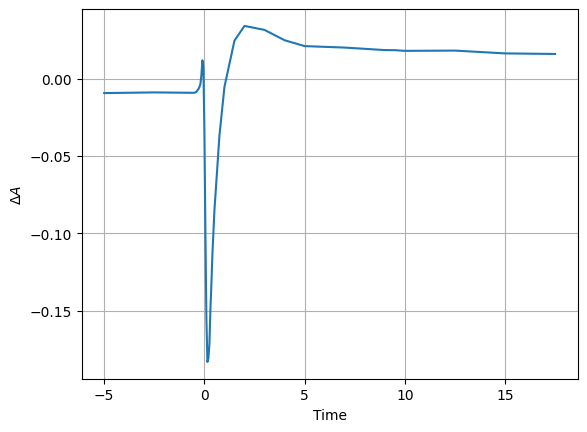

<Axes: xlabel='Time', ylabel='$\\Delta A$'>

In [23]:
stack.avg_show()

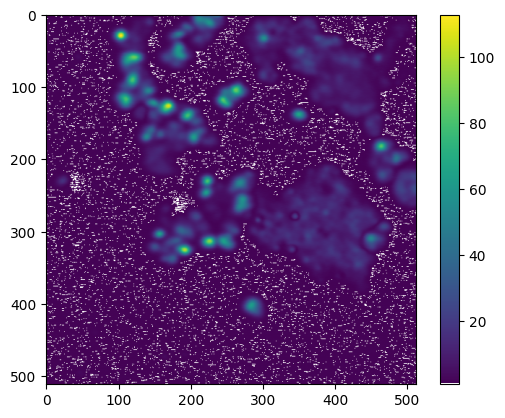

<Axes: >

In [24]:
stack.project_show()

## Processing

### Subtracting the mean of the first few images and downsampling

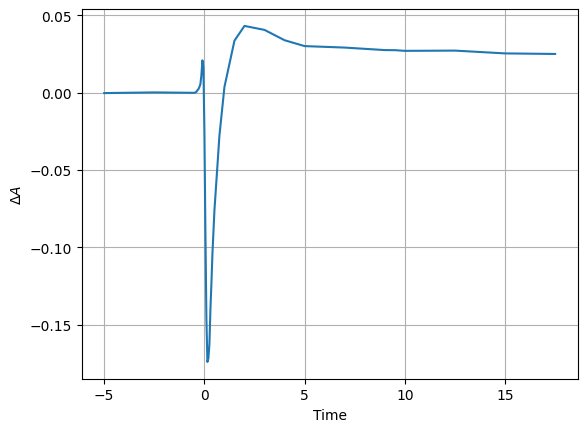

<Axes: xlabel='Time', ylabel='$\\Delta A$'>

In [25]:
stack.subtractFirst(n=3).avg_show()

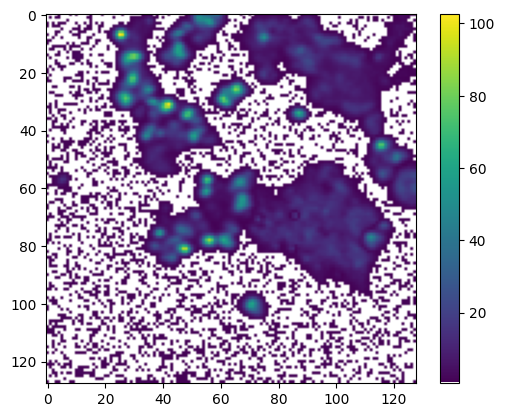

<Axes: >

In [26]:
stack.subtractFirst(n=3).downsample(4).project_show()

### intensity threshold

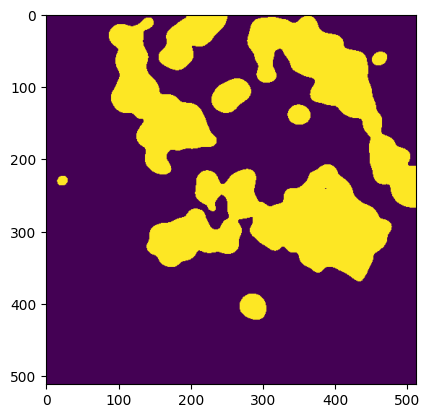

In [27]:
mask = stack.intensity_threshold()
plt.imshow(mask)
plt.show()

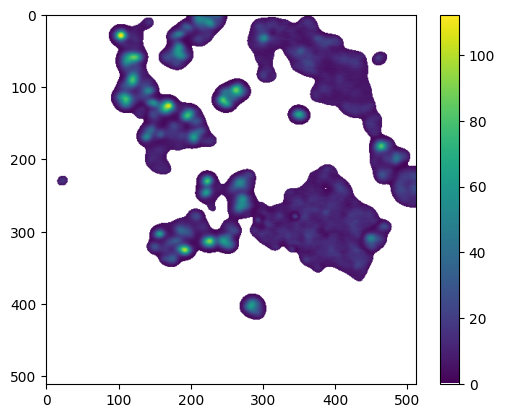

<Axes: >

In [28]:
stack.intensity_threshold(inplace=True)
stack.project_show()

### derive substacks

In [29]:
substacks = stack.substacks(128)
print(f"Number of substacks: {len(substacks)}")

Number of substacks: 16


IndexError: index 4 is out of bounds for axis 0 with size 4

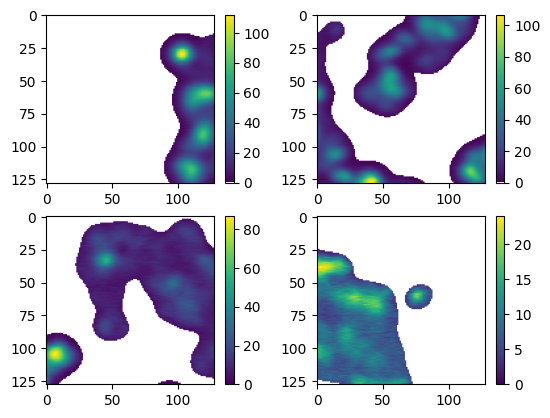

In [30]:
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
for i, substack in enumerate(substacks):
    substack.project_show(ax=axes[i])

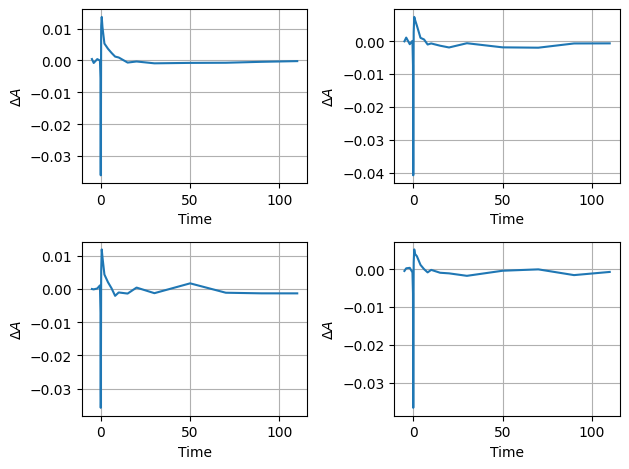

In [ ]:
fig, ax = plt.subplots(2, 2)
ax = ax.flatten()
for i, substack in enumerate(substacks):
    substack.avg_show(ax=ax[i])

plt.tight_layout()

### Phasor

In [ ]:
phasor = stack.phasor()

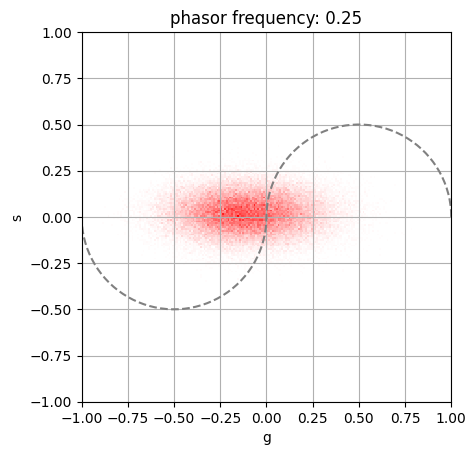

<Axes: title={'center': 'phasor frequency: 0.25'}, xlabel='g', ylabel='s'>

In [ ]:
stack.phasor_show()